# Spatial means and climate indices

All of the spatial reductions are area-weighted using the grid metadata that `x4c`
attached when the file was opened.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
fpath = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(fpath, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
da = ds.x.da.x.annualize()
da

<conda-env>/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.DataArray 'TS' (time: 5, ncol: 13826)> Size: 277kB
array([[300.71176, 300.23596, 299.48703, ..., 297.07526, 295.2403 ,
        296.43073],
       [299.7446 , 299.18985, 298.37283, ..., 297.8188 , 296.21884,
        297.1547 ],
       [299.12976, 298.63388, 297.93066, ..., 297.27213, 295.7419 ,
        296.82455],
       [299.12024, 298.5114 , 297.6068 , ..., 298.5577 , 297.19064,
        298.1517 ],
       [298.96866, 298.3304 , 297.4125 , ..., 298.67502, 297.13403,
        297.96326]], shape=(5, 13826), dtype=float32)
Coordinates:
  * time     (time) object 40B 0001-12-31 00:00:00 ... 0005-12-31 00:00:00
    lat      (ncol) float64 111kB ...
    lon      (ncol) float64 111kB ...
Dimensions without coordinates: ncol
Attributes:
    units:         K
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
    path:          ~/.cache/x4c/sample_data/cesm1_sample_...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4

## Global and hemispheric

`gm`/`nhm`/`shm` are means; `gs`/`nhs`/`shs` are the corresponding area-weighted
sums. All are properties, not methods.

In [3]:
print(f'global mean : {float(da.x.gm[0]):8.3f} K')
print(f'NH mean     : {float(da.x.nhm[0]):8.3f} K')
print(f'SH mean     : {float(da.x.shm[0]):8.3f} K')
print()
print(f'global sum  : {float(da.x.gs[0]):.4e} K m^2')

global mean :  296.395 K
NH mean     :  295.597 K
SH mean     :  297.059 K

global sum  : 3.7246e+03 K m^2


The weight has to span dimensions the data actually has. If it does not — which
can happen if you build a `DataArray` by hand and attach a mismatched weight — the
reduction refuses rather than silently broadcasting into a much larger array.

In [4]:
bad = da.copy()
bad.attrs['gw'] = xr.DataArray(np.ones(10), dims='not_a_real_dim')
try:
    bad.x.gm
except ValueError as e:
    print('ValueError:', str(e)[:150], '...')

ValueError: The area weight `gw` spans dims ('not_a_real_dim',), which are not all present in the data dims ('time', 'ncol') (missing: ['not_a_real_dim']). The we ...


## Zonal mean

`.x.zm` averages over longitude. On an unstructured grid there is no longitude axis
to average over, so `zm` regrids to a regular grid first.

('time', 'lat') (5, 180)


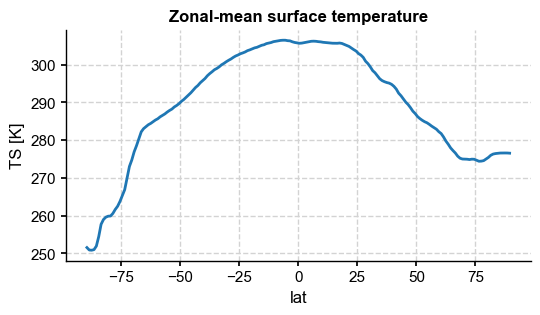

In [5]:
zm = da.x.zm
print(zm.dims, zm.shape)

fig, ax = zm.mean('time').x.plot(title='Zonal-mean surface temperature')
x4c.showfig(fig)

## Regional means

`geo_mean` takes an explicit `latlon_range` as `(lat_min, lat_max, lon_min, lon_max)`,
with longitudes in 0-360.

In [6]:
tropics = da.x.geo_mean(latlon_range=(-30, 30, 0, 360))
southern = da.x.geo_mean(latlon_range=(-90, -60, 0, 360))

print(f'tropical mean (30S-30N) : {float(tropics[0]):.3f} K')
print(f'polar mean (90S-60S)    : {float(southern[0]):.3f} K')

tropical mean (30S-30N) : 304.868 K
polar mean (90S-60S)    : 275.178 K


## Named climate indices

Common index boxes are built in, so you do not have to remember the coordinates.
Available: `nino3.4`, `nino1+2`, `nino3`, `nino4`, `wpi`, `tpi`, `dmi`, `iobw`.

In [7]:
monthly = ds.x.da  # indices are usually computed on monthly data
for ind in ['nino3.4', 'nino3', 'nino4', 'wpi']:
    v = monthly.x.geo_mean(ind=ind)
    print(f'{ind:9s} mean over the record: {float(v.mean()):.3f} K')

nino3.4   mean over the record: 305.432 K
nino3     mean over the record: 304.802 K
nino4     mean over the record: 306.208 K
wpi       mean over the record: 307.178 K


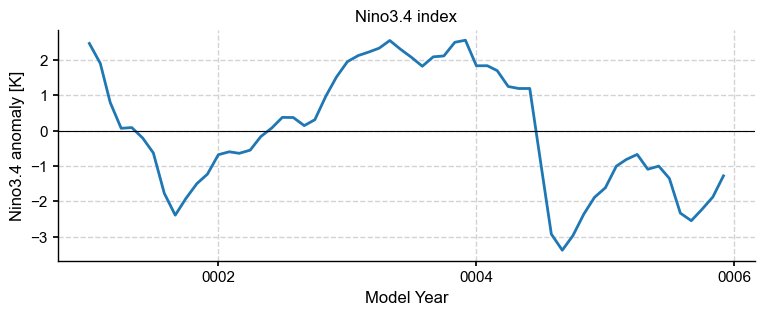

In [8]:
nino34 = monthly.x.geo_mean(ind='nino3.4')
nino34_anom = nino34 - nino34.mean('time')

fig, ax = nino34_anom.x.plot(figsize=(9, 3))
ax.axhline(0, color='k', lw=0.8)
ax.set(ylabel='Nino3.4 anomaly [K]', title='Nino3.4 index')
x4c.showfig(fig)